## Analisando dados de vendas de video games

### Quais são os 10 jogos mais vendidos? E como é a venda desses para cada plataforma?

In [5]:
import pandas as pd
import plotly.express as px

In [34]:
df = pd.read_csv("projeto_guiado/vgchartz-2024.csv")
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  str    
 1   title         64016 non-null  str    
 2   console       64016 non-null  str    
 3   genre         64016 non-null  str    
 4   publisher     64016 non-null  str    
 5   developer     63999 non-null  str    
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  str    
 13  last_update   17879 non-null  str    
dtypes: float64(6), str(8)
memory usage: 6.8 MB


In [8]:
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


In [9]:
for col in ['title', 'console', 'genre', 'publisher', 'developer']:
    print(df[col].value_counts())
    print('='*50)

title
Plants vs. Zombies                  17
Pac-Man                             16
Monopoly                            15
Doom                                14
Double Dragon                       14
                                    ..
Without Within                       1
Without Within 2                     1
Without Within 3                     1
Yunohana SpRING! ~Mellow Times~      1
Yurukill: The Calumniation Games     1
Name: count, Length: 39798, dtype: int64
console
PC      12617
PS2      3565
DS       3288
PS4      2878
PS       2707
        ...  
TG16        3
FDS         1
C128        1
Aco         1
BBCM        1
Name: count, Length: 81, dtype: int64
genre
Misc                9304
Action              8557
Adventure           6260
Role-Playing        5721
Sports              5586
Shooter             5410
Platform            4001
Strategy            3685
Puzzle              3521
Racing              3425
Simulation          3158
Fighting            2367
Action-Adventure  

### Como foi a venda de jogos por ano para as distribuidoras que mais venderam?

In [12]:
jogos_mais_vendidos = df.groupby(['title'])['total_sales'].sum().sort_values(ascending=False)
top_jogos = pd.DataFrame({'titulos':jogos_mais_vendidos.index, 'vendas':jogos_mais_vendidos.values})

top_10_jogos = top_jogos[0:10]

top_10_jogos = top_10_jogos.sort_values(by='titulos')


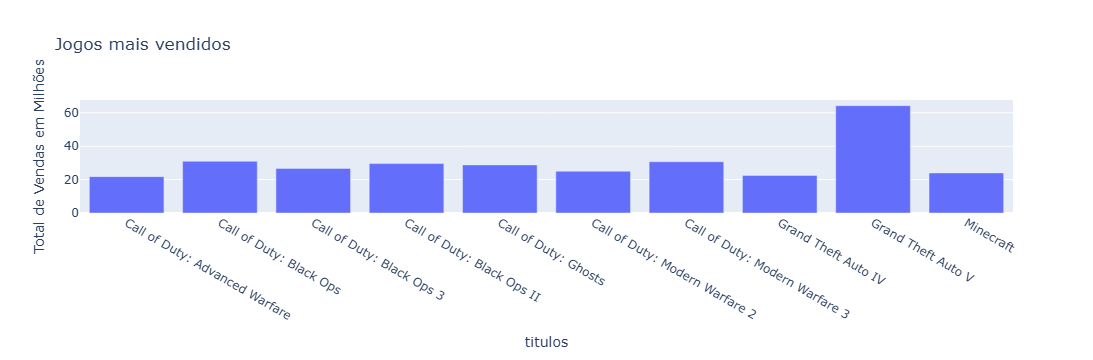

In [14]:
px.bar(top_10_jogos, x='titulos', y='vendas', title='Jogos mais vendidos',
       labels={
           "vendas": "Total de Vendas em Milhões",
           "titulo": "Título do Jogo",
       })

In [35]:
print(type(df))
print(type(top_10_jogos))

print(df.shape)
print(top_10_jogos.shape)

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
(64016, 14)
(10, 2)


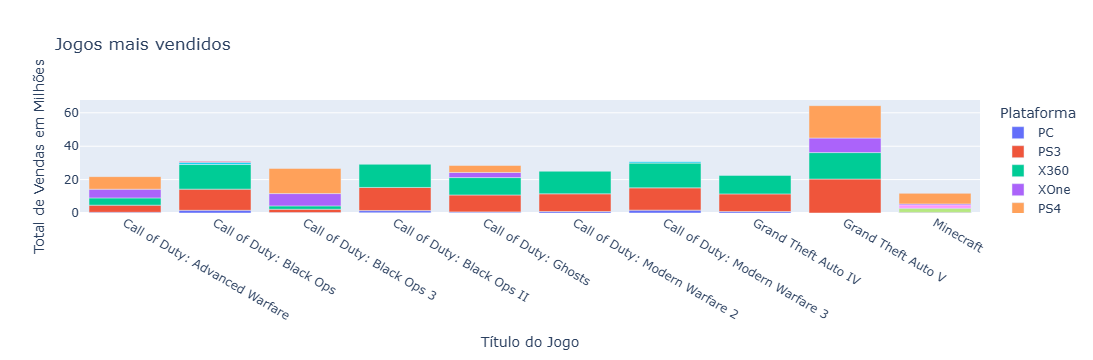

In [37]:
df_top_games = df[df['title'].isin(top_10_jogos['titulos'].unique())]

df_top_games = df_top_games.sort_values(by='title')

px.bar(
    df_top_games,
    x='title',
    y='total_sales',
    color='console',
    title='Jogos mais vendidos',
    labels={
        "total_sales": "Total de Vendas em Milhões",
        "title": "Título do Jogo",
        "console": "Plataforma"
    }
)


### A nota de um jogo influência as suas vendas?

### Como variam as notas de acordo com o gênero?        

### Como varia o número de vendas de jogos em cada região?
